In [1]:
# 全局设置
import os
import datetime as dt
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings('ignore', category=PerformanceWarning)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False# 正确显示负号
from IPython.display import HTML

# 因子测试

**Rank IC**：往期因子值和当期收益率的秩相关性。通常采用的相关系数为 Spearman 相关系数。记收益率的横截面向量 $R_{i,t}$ 的截面排名记为 $Q_{i,t}$, 在 $t-1$ 时刻因子暴露的横截面向量 $\beta_{i,t}$ 的截面排名记为 $P_{i,t}$, 那么 $t$ 时刻的 Rank IC 定义为: 
$$
\rho \left( Q_{t},P_{t-1} \right) = \frac{\sum\limits_{i=1}^{N}{\left( Q_{i,t} - \bar{Q}_{t} \right) \left( P_{i,t-1}-\bar{P}_{t-1} \right)}}{\sqrt{\sum\limits_{i=1}^{N}{{{\left( Q_{i,t} - \bar{Q}_{t} \right)}^{2}}}\cdot \sum\limits_{i=1}^{N}{{{\left( P_{i,t-1}-\bar{P}_{t-1} \right)}^{2}}}}}
$$
其中: 
$$
\begin{aligned}
& \bar{Q}_{t} = \frac{1}{N}\sum\limits_{i=1}^{N}Q_{i,t}\\
& \bar{P}_{t-1} = \frac{1}{N}\sum\limits_{i=1}^{N}P_{i,t-1}
\end{aligned}
$$
另外还可以计算行业调整的 IC：扣除行业收益率后的 Rank IC. 对于股票 i, 其收益率 $R_{i,t}$ 的行业调整值定义为 $\tilde{R}_{i,t}=R_{i,t}-R_{I,t}$, 其中, $R_{I,t}$ 为行业 I 在时段 $[t-1,t]$ 的收益率, 即 $R_{I,t}=\sum\limits_{i\in I}{w_{i,t-1}\cdot R_{i,t}}$, $w_{i,t}$ 为 t 时刻股票 i 在行业 I 中所占的权重, 通常可取等权或者按照某个指标加权。对于因子 j , 行业调整的 Rank IC 即为调整后的收益率 $\tilde{R}_{i,t}$ 同 $\beta_{j,t}$ 的 Rank IC。

**IC的衰减**：因子值和收益率关于日期间隔的 IC 衰减情况。对于因子 j，分别计算 $R_t$ 同 $\beta _{j,t-1},\beta _{j,t-2},\ldots ,\beta _{j,t-K}$ 的Rank IC, 考察 Rank IC 序列关于时间间隔 $\left(1,2,\ldots ,K \right)$ 的变化情况。

**分位数组合**：按因子值排序分组后形成的投资组合. 对于目标因子, 在时刻 t，首先剔除因子值缺失和不符合筛选条件的证券，对剩下的证券按照因子暴露进行排序，把排序后的证券平均分成 K 组（一般取 5 或者 10 组），每一组构建投资组合（通常为等权或者按照某个因子值加权），测试给定时间段每一组合的表现情况。计算每一组的收益率，年化收益率，波动率等指标。

**因子换手率**：当期因子值和上期因子值横截面上的线性相关系数。对于给定因子，因子暴露的横截面向量 $\beta_{i,t}$ 的截面排名记为 $P_{i,t}$，日期 t 和上一日期 t-1 之间的换手率定义为: 
$$
\rho \left( P_{t}, P_{t-1} \right) = \frac{\sum\limits_{i=1}^{N}{\left( P_{i,t} - \bar{P}_{t} \right) \left( P_{i,t-1} - \bar{P}_{t-1} \right)}} {\sqrt{\sum\limits_{i=1}^{N}{{{\left( P_{i,t}-\bar{P}_{t} \right)}^{2}}}\cdot \sum\limits_{i=1}^{N}{{{\left( P_{i,t-1}-\bar{P}_{t-1} \right)}^{2}}}}}
$$

**Fama-MacBeth 回归**：剥离了给定风险因子后的因子收益率. 给定 K 个风险因子（一般取市值, Beta, 行业等）, 记股票 i 在这些风险因子上的暴露为 $\beta_{i,1,t},\beta_{i,2,t},\ldots ,\beta_{i,K,t}$ , 对于目标因子, 在时刻 t , 同风险因子一起与收益率向量 $\mathbf{R}_t$ 做横截面回归, 即: 
$$
R_{i,t} = f^*_{t}\beta^*_{i,t-1} + f_{1,t}\cdot \beta_{i,1,t-1}+ \cdots +f_{K,t}\cdot \beta_{i,K,t-1} + \varepsilon_{i,t}
$$
估计的回归系数 $f^*_{t}$ 即为剥离了这 K 个风险因子后目标因子在时段 t 的收益。 

**因子相关性**：两个因子暴露的相关性. 取时刻 t 的因子 i 和因子 j 的因子暴露 $\beta_{i,t}$、$\beta_{j,t}$ , 在横截面上计算相关性, 方法可以选择: spearman, pearson, kendall 以及 factor-score correlation. 

In [2]:
# 参数设置
from QuantStudio.Factor.HDF5DB import HDF5DB
HDB = HDF5DB(args={"MainDir": "../data/HDF5"}).connect()

StartDT, EndDT = dt.datetime(2025, 1, 1), dt.datetime(2025, 3, 31)# 数据起止时间
TestStartDT, TestEndDT = dt.datetime(2025, 2, 28), EndDT# 测试起止时间

FT = HDB.getTable("stock_cn_day_bar")
DTRuler = FT.getDateTime(start_dt=StartDT, end_dt=EndDT)
TestDTs = FT.getDateTime(start_dt=TestStartDT, end_dt=TestEndDT)
SectionIDs = IDs = FT.getID()

# 再平衡时点序列
from QuantStudio.Tools.DateTimeFun import getMonthLastDateTime
BalanceDTs = getMonthLastDateTime(DTRuler)# 月末


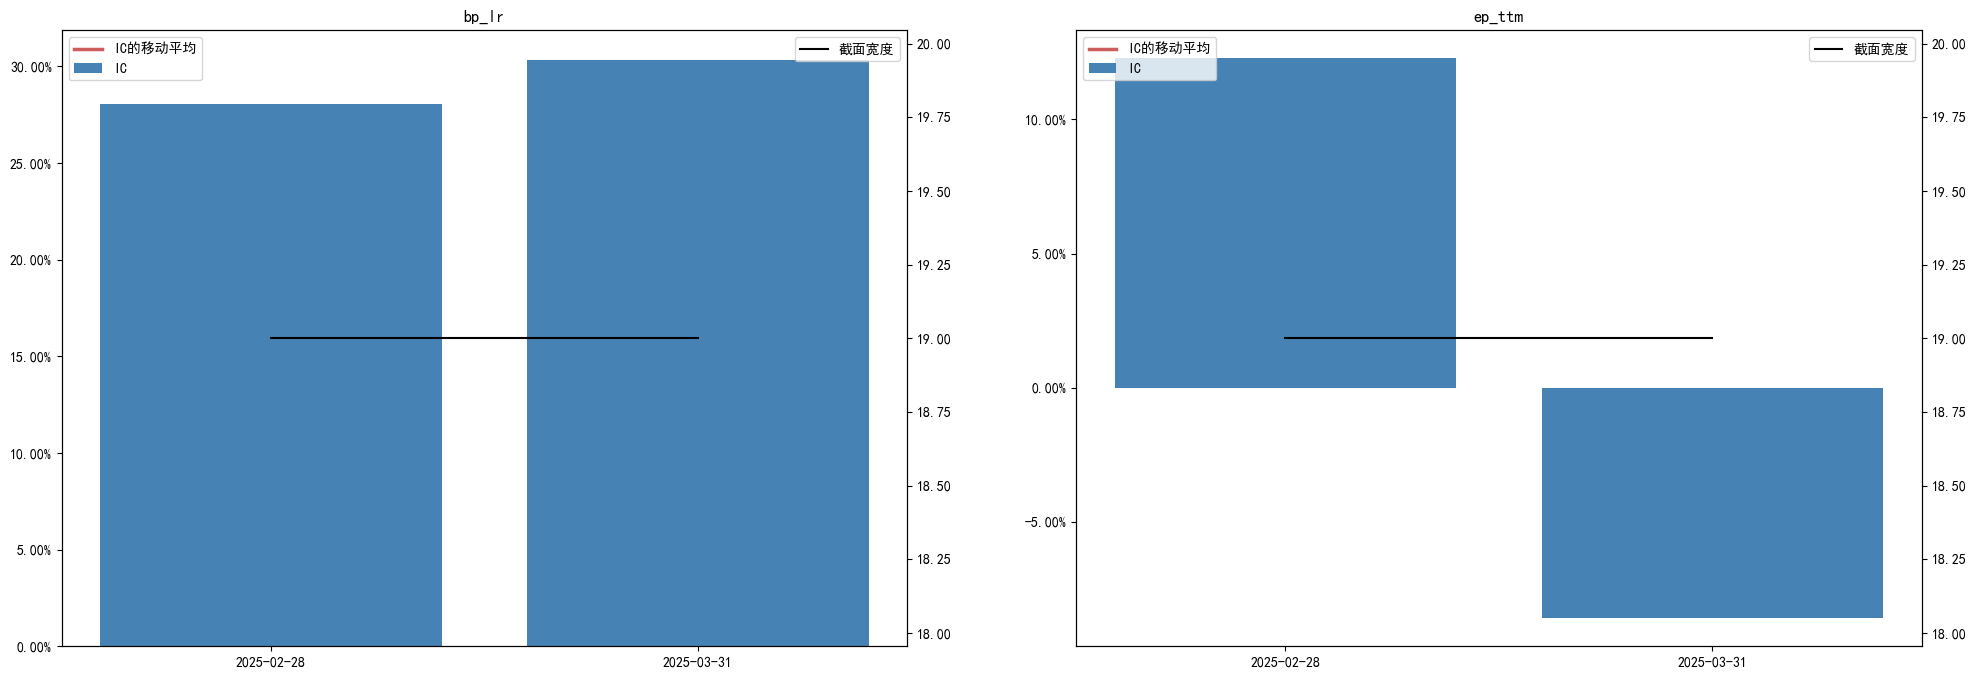
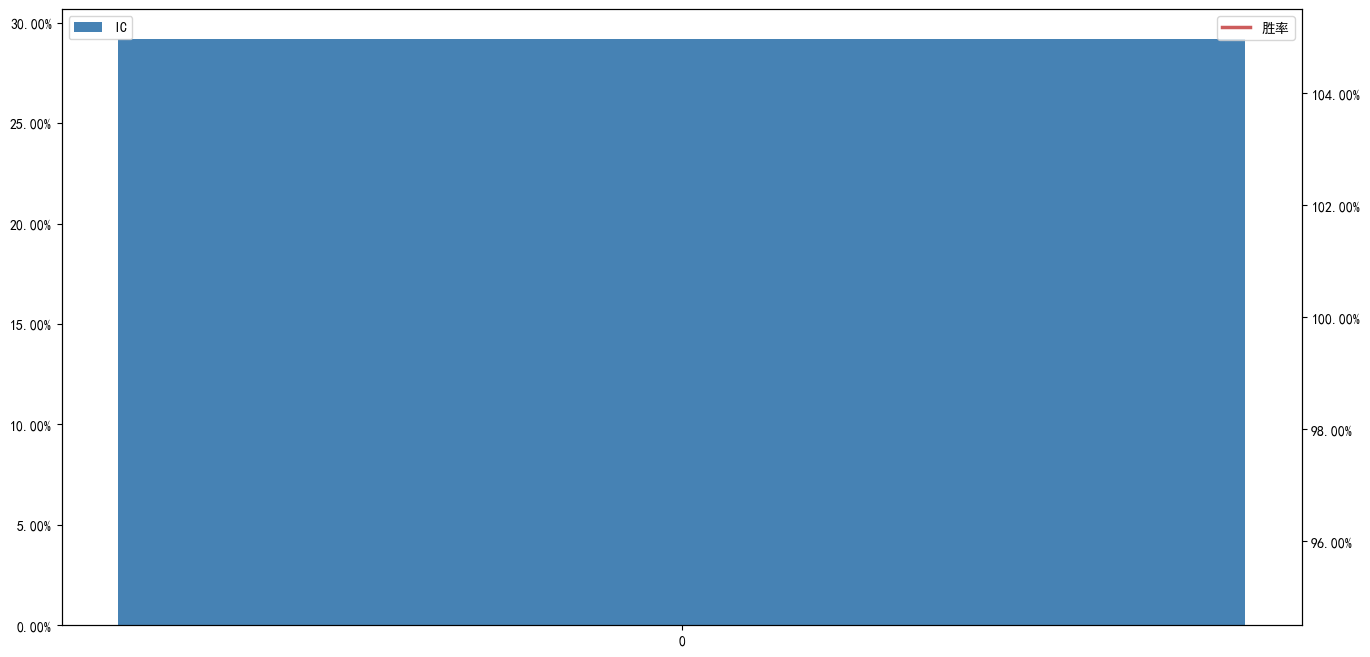
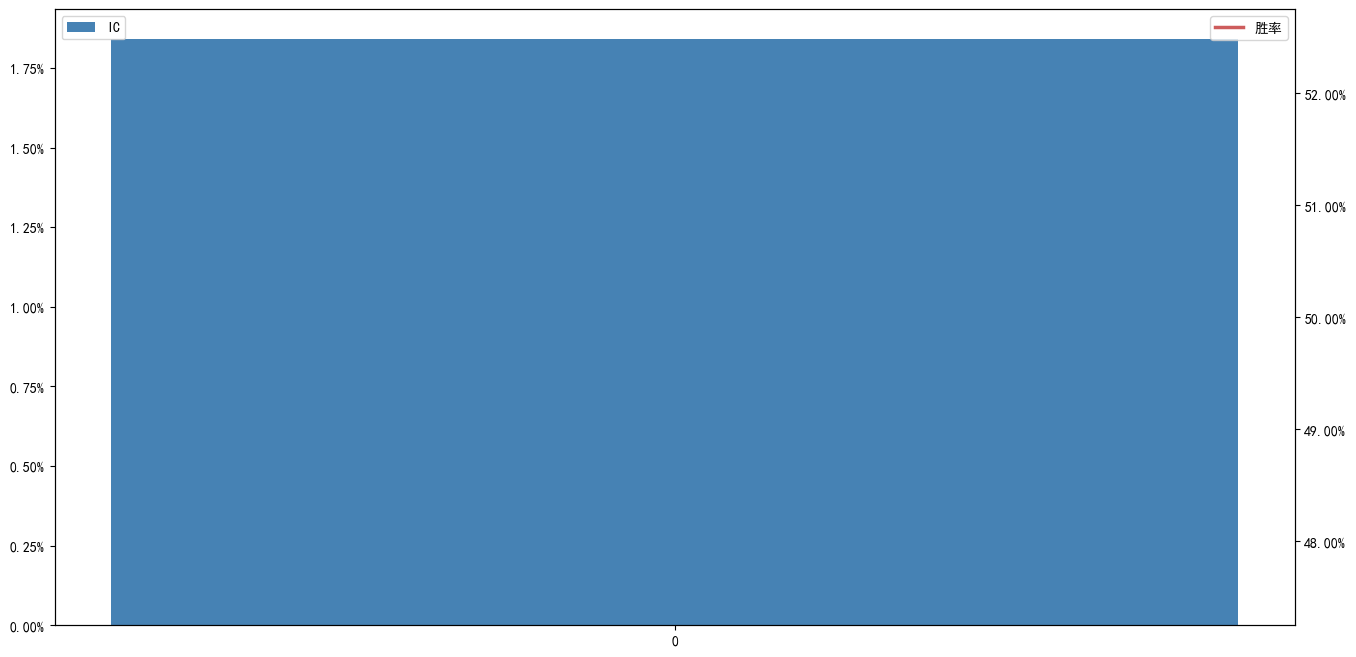
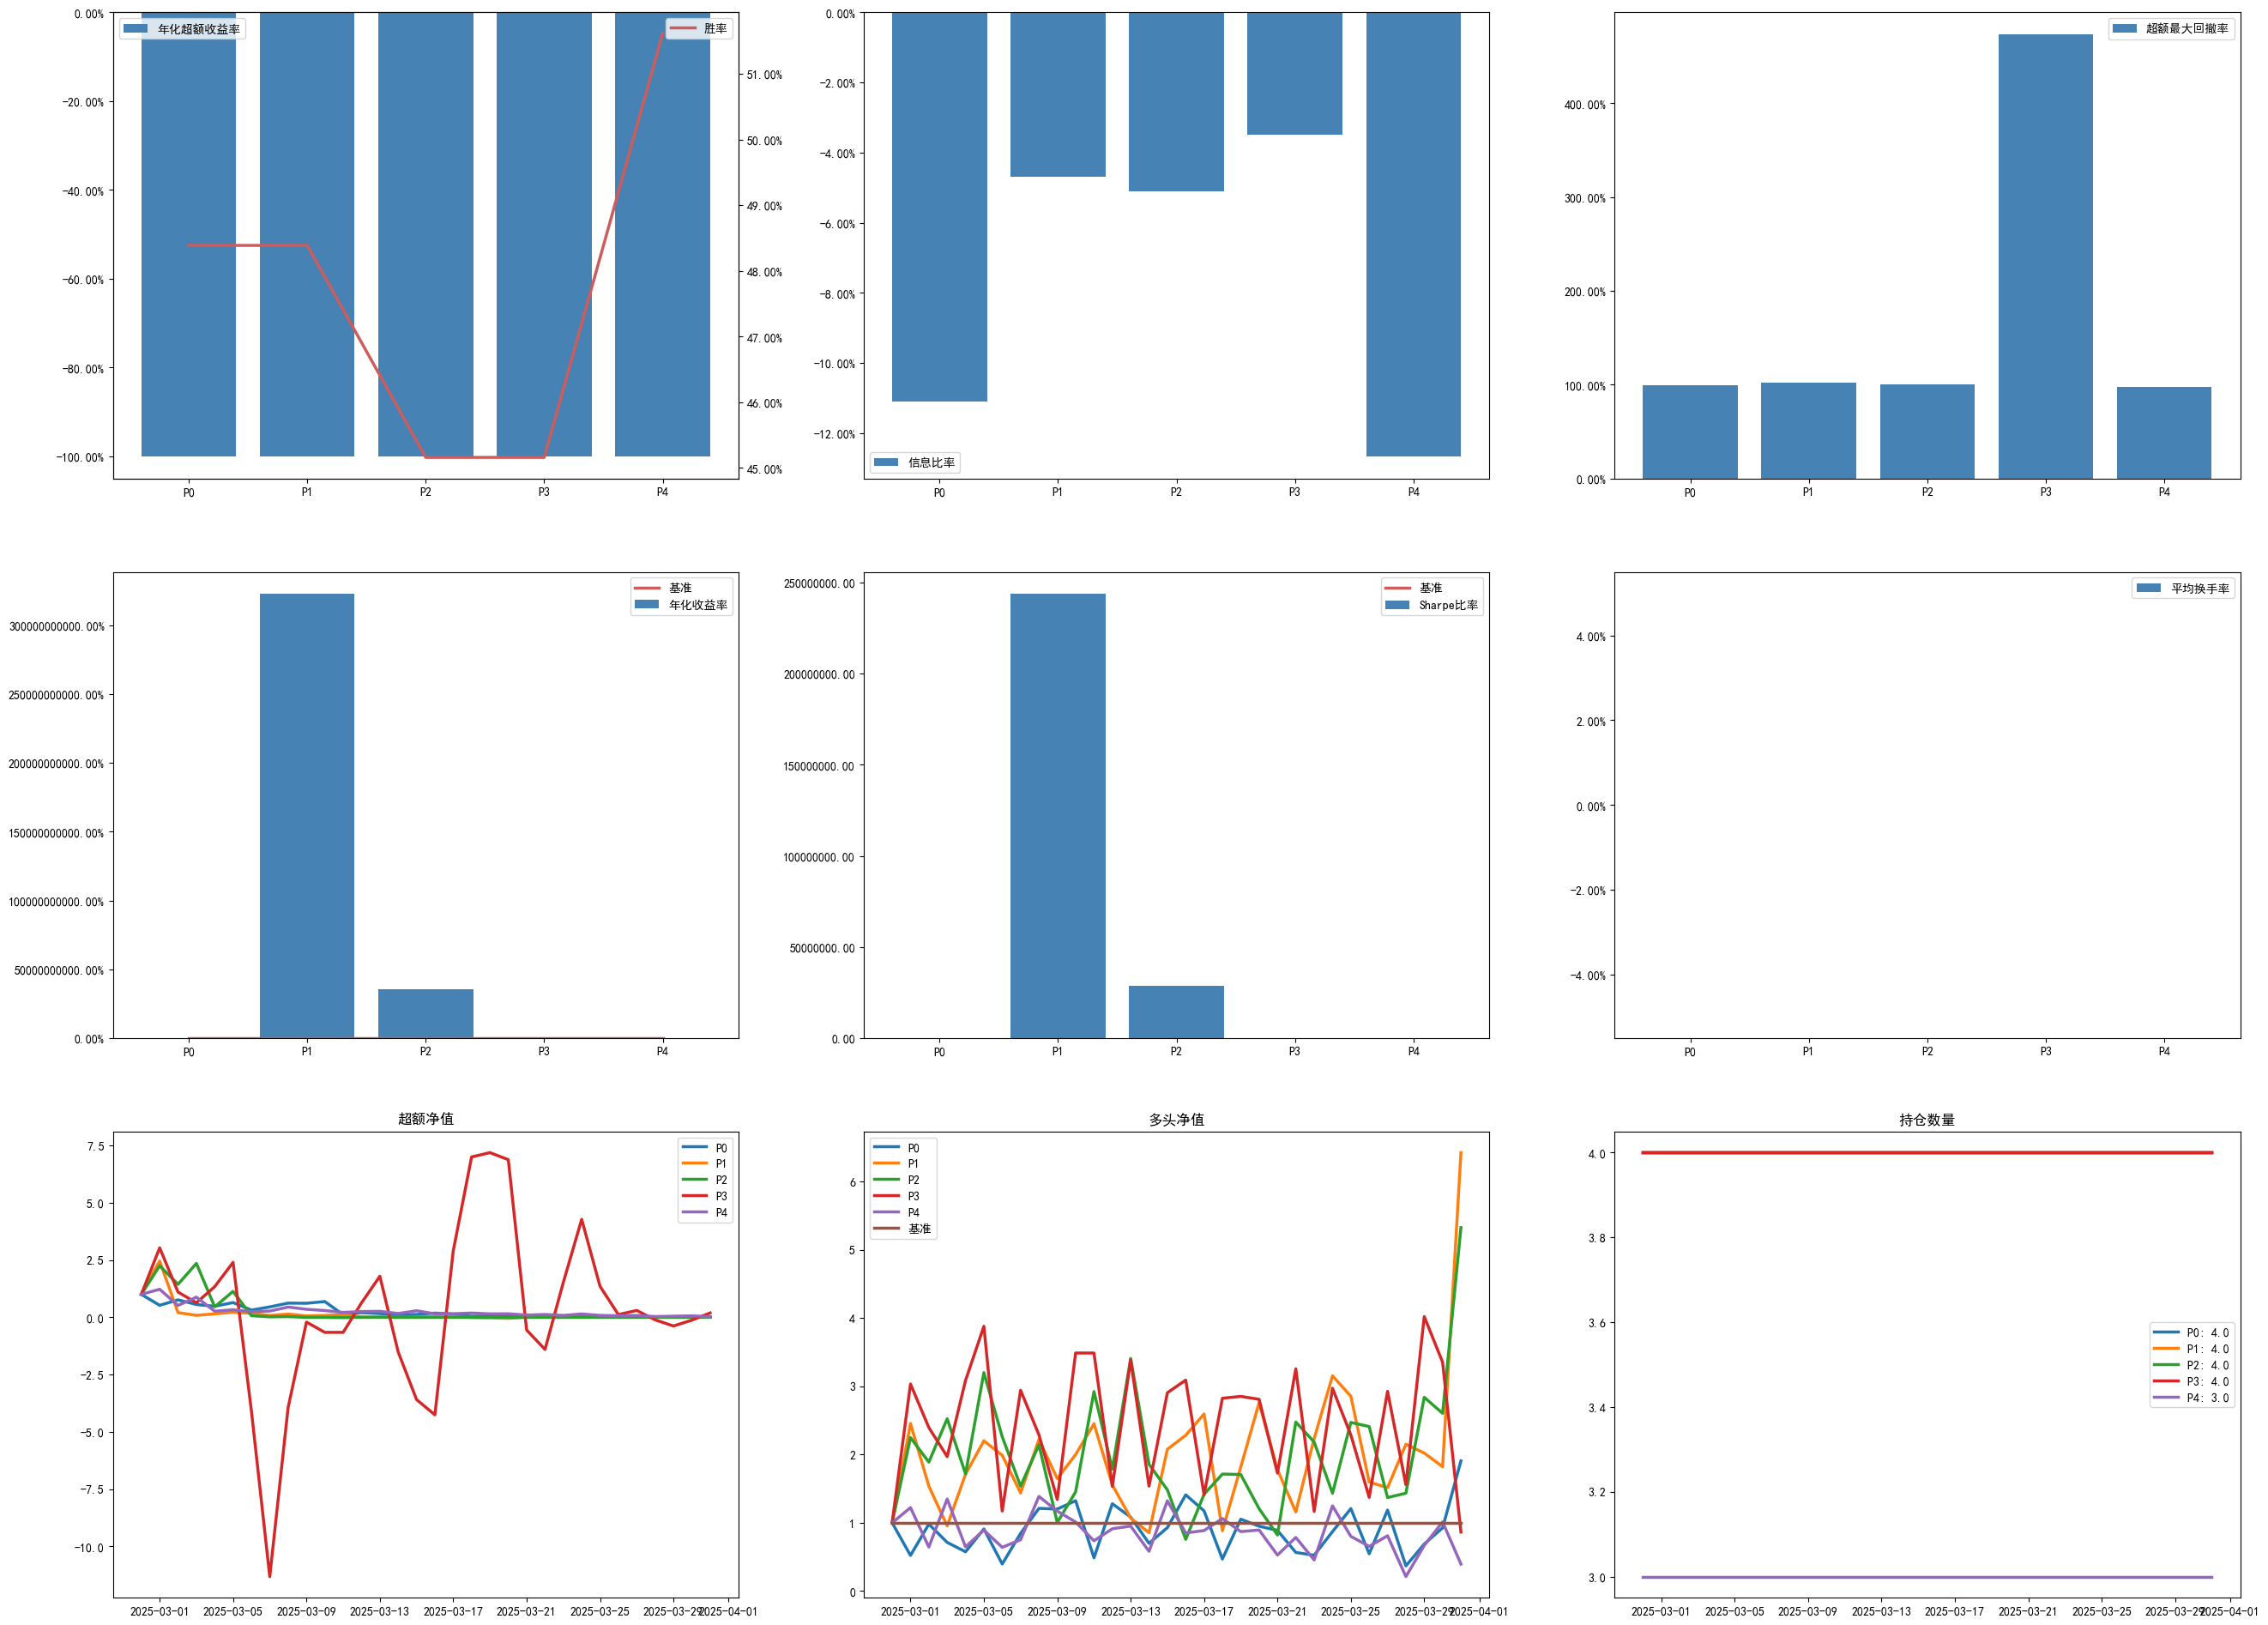
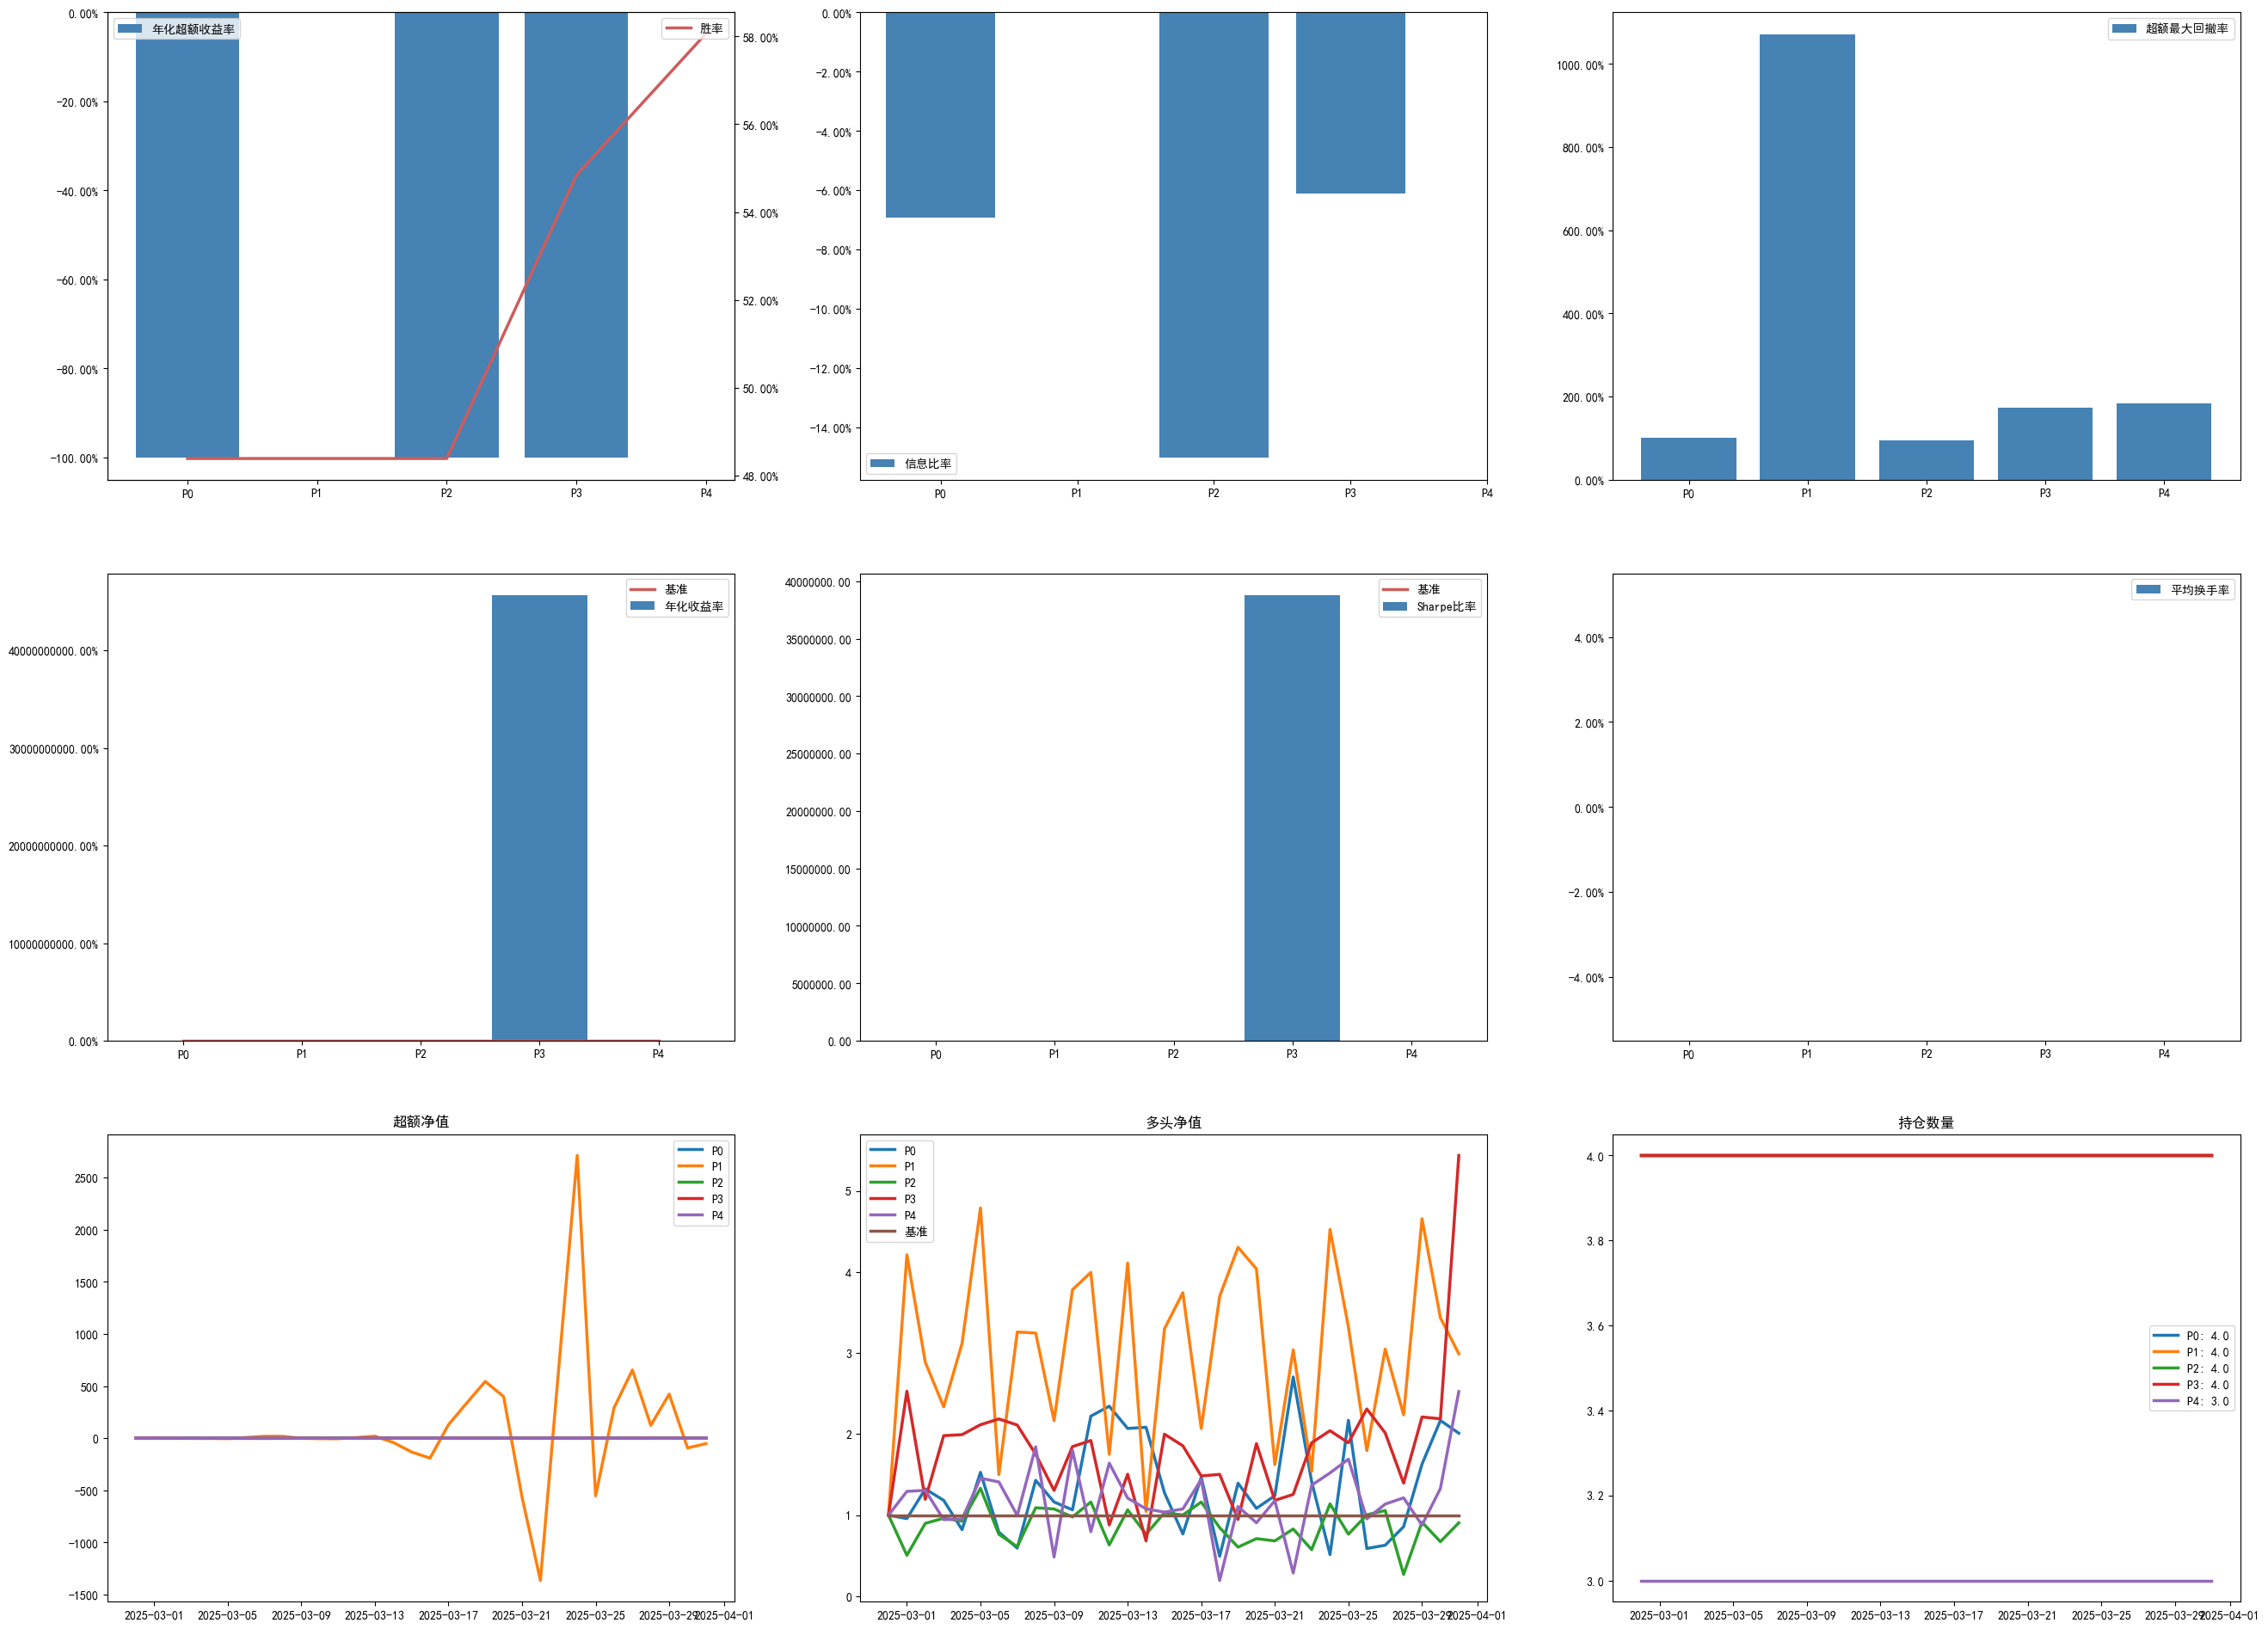
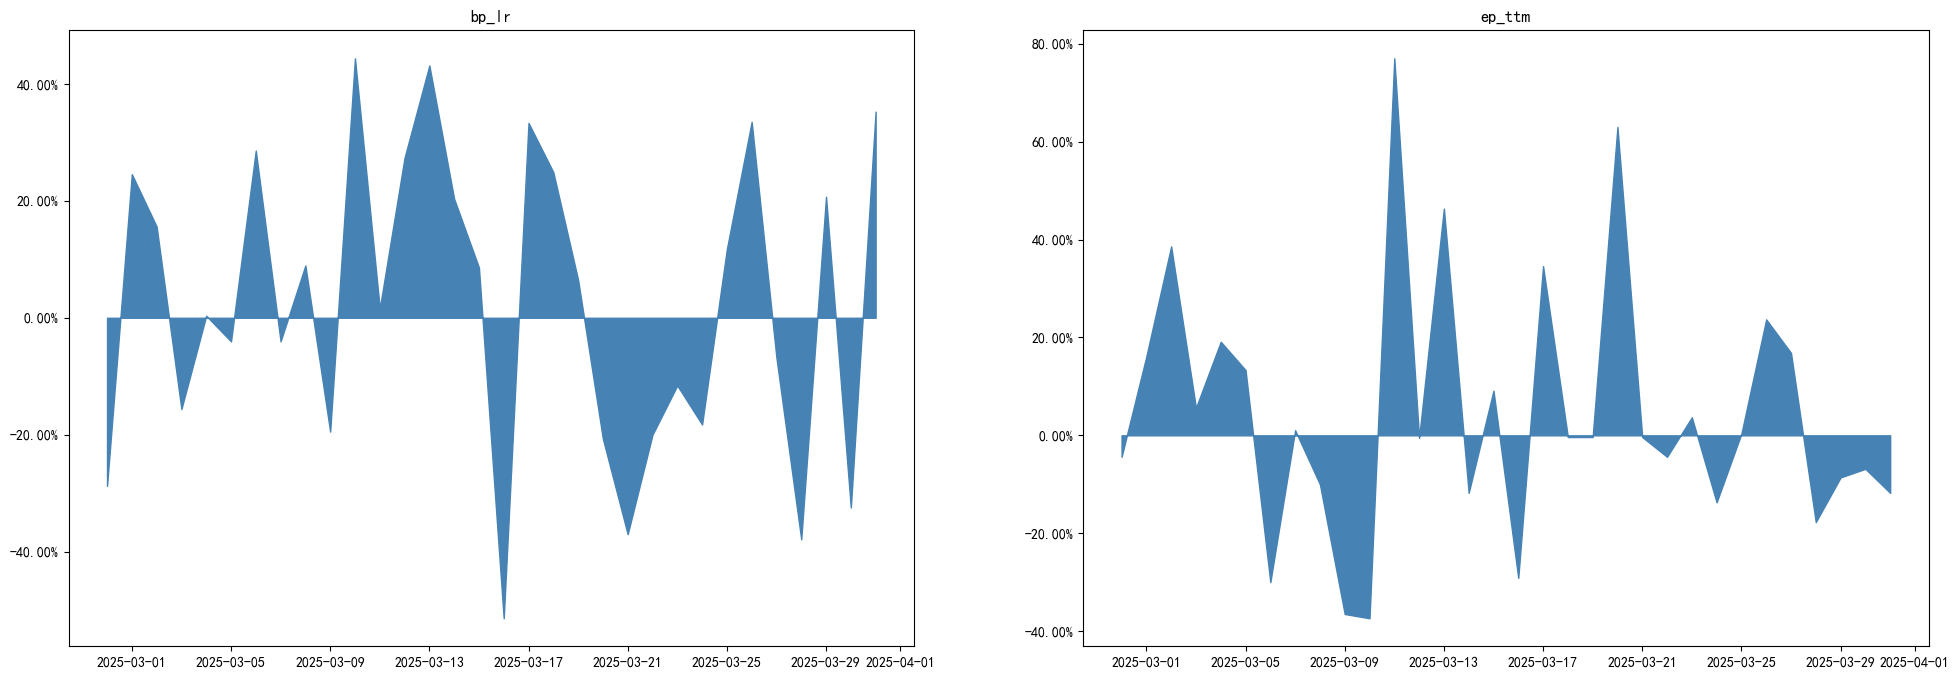
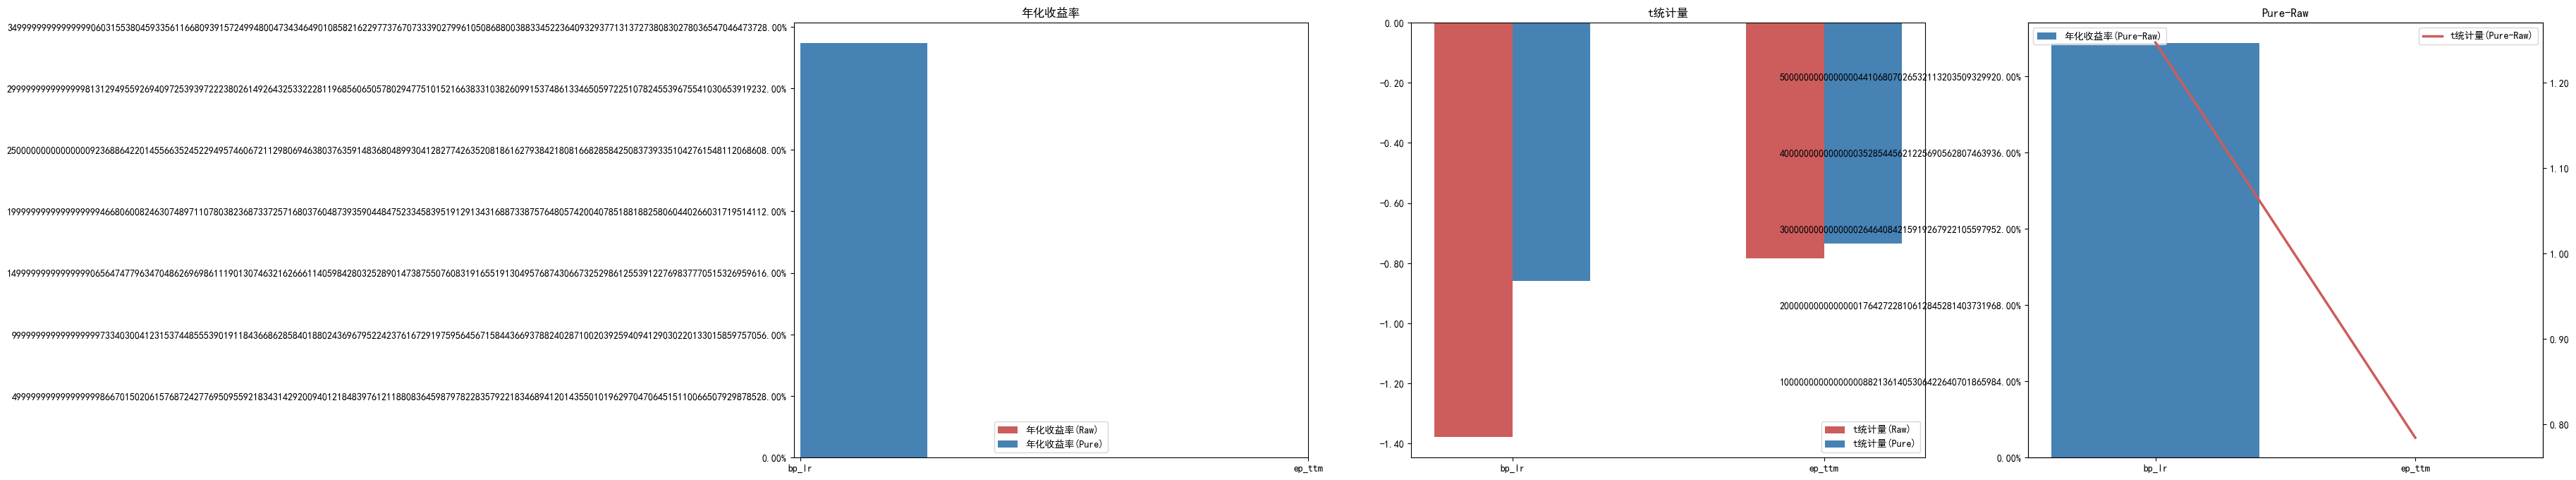

In [ ]:
# 因子测试
from QuantStudio.Core.CalcEngine import Engine, ParallelEngine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport
from QuantStudio.BackTest.SectionFactor.IC import CalcIC, IC, ICDecay
from QuantStudio.BackTest.SectionFactor.Portfolio import makeQuantilePortfolio, MultiPortfolio, CalcPortfolioNV
from QuantStudio.BackTest.SectionFactor.Correlation import CalcFactorTurnover, FactorTurnover, CalcSectionCorrelation, SectionCorrelation
from QuantStudio.BackTest.SectionFactor.ReturnDecomposition import CalcFamaMacBethRegression, FamaMacBethRegression

FT = HDB.getTable("stock_cn_status")
Mask = (FT.getFactor("if_listed")==1)

FT = HDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = HDB.getTable("stock_cn_industry")
Industry = FT.getFactor("industry")

FT = HDB.getTable("stock_cn_factor_value")
FactorList = [FT.getFactor(iFactorName) for iFactorName in ["bp_lr", "ep_ttm"]]

# 回测节点列表
NodeList = []

# Rank IC
FactorIC = CalcIC(descriptor_ids=SectionIDs, lookback=31, period_lookback=1, corr_method="spearman")(*FactorList, price=Price, mask=Mask, cat_data=Industry, factor_args={"CalcDTRuler": BalanceDTs})
ICNode = IC(FactorIC, args={"RollingAvgPeriod": 2, "GenReport": True})
NodeList.append(ICNode)

# IC 衰减
ICDecayNode = ICDecay(ic_list=[CalcIC(descriptor_ids=SectionIDs, lookback=31*i, period_lookback=i)(*FactorList, price=Price, mask=Mask, cat_data=Industry, factor_args={"CalcDTRuler": BalanceDTs}) for i in range(1, 2)], args={"GenReport": True})
NodeList.append(ICDecayNode)

# 分位数组合
calcPortfolioNV = CalcPortfolioNV(descriptor_ids=SectionIDs, start_dt=TestDTs[0])
for iFactor in FactorList:
    iQuantilePortfolioList = makeQuantilePortfolio(iFactor, mask=Mask, cat_data=Industry, weight=None, descriptor_ids=SectionIDs, rebalance_dts=BalanceDTs, group_num=5)
    iPortfolioNV = calcPortfolioNV(*iQuantilePortfolioList, price=Price, init_nv=1)
    iQuantilePortfolioNode = MultiPortfolio(nv=iPortfolioNV, portfolio_list=iQuantilePortfolioList, args={"RebalanceDTs": BalanceDTs, "GenReport": True, "Name": f"{iFactor.Name}-分位数组合"})
    NodeList.append(iQuantilePortfolioNode)

# 因子换手率
TurnoverFactor = CalcFactorTurnover(descriptor_ids=SectionIDs, lookback=31, period_lookback=1)(*FactorList, mask=Mask)
FactorTurnoverNode = FactorTurnover(TurnoverFactor, args={"GenReport": True})
NodeList.append(FactorTurnoverNode)

# 截面相关性
SectionCorrelationFactor = CalcSectionCorrelation(descriptor_ids=SectionIDs)(*FactorList, mask=Mask)
SectionCorrelationNode = SectionCorrelation(SectionCorrelationFactor, args={"GenReport": True})
NodeList.append(SectionCorrelationNode)

# Fama-MacBeth 回归
FamaMacBethFactor = CalcFamaMacBethRegression(descriptor_ids=SectionIDs)(*FactorList, price=Price, mask=Mask, cat_data=Industry)
FamaMacBethNode = FamaMacBethRegression(FamaMacBethFactor, args={"GenReport": True})
NodeList.append(FamaMacBethNode)

Report = BTReport(bt_node_list=NodeList)

with FeatherFactorCache(args={"DTRuler": DTRuler, "PIDs": ["0"], "CacheDir": "../data/Cache", "StartMode": "new"}) as Cache:
    with FactorContext(PID="0", PIDList=["0"], DTRuler=DTRuler, SectionIDs=SectionIDs, DataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Output, = ExecEngine.run([Report], Context, fwd_data_list=[DTLocalContext(DTs=TestDTs)], init_data_list=[DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Output["Report"]))